# ***Task 3: Linear Regression***

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Saving Housing.csv to Housing.csv


In [2]:
df = pd.read_csv('Housing.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Data Preprocessing**

In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

**Simple Linear Regression**

In [8]:
X_simple = df[['area']]
y_simple = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

**Evaluate Simple Linear Regression**

In [9]:
mae_s = mean_absolute_error(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("Simple Linear Regression Results")
print("MAE:", mae_s)
print("MSE:", mse_s)
print("R² Score:", r2_s)

Simple Linear Regression Results
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


**Plot Regression Line**

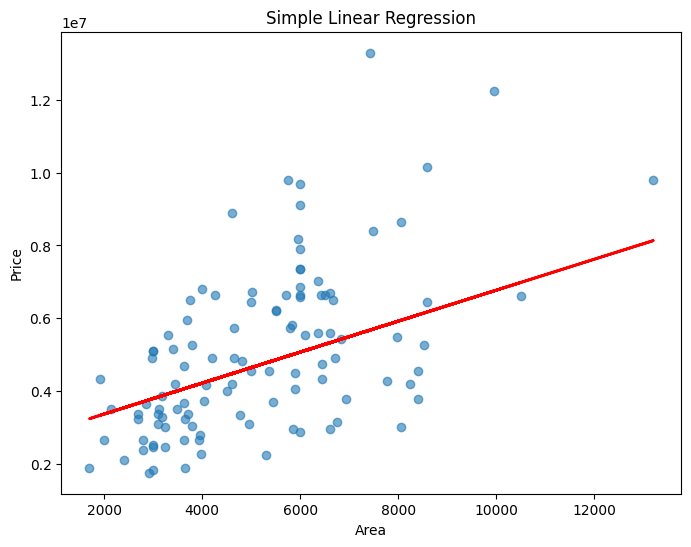

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(X_test_s, y_test_s, alpha=0.6)

plt.plot(
    X_test_s,
    y_pred_s,
    color='red',
    linewidth=2
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()

**Multiple Linear Regression**

In [11]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

y_pred = multi_model.predict(X_test)

**Evaluate Multiple Linear Regression**

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Multiple Linear Regression Results
MAE: 970043.4039201636
MSE: 1754318687330.6638
R² Score: 0.6529242642153184


**Interpret Coefficients**

In [13]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


**Actual vs Predicted Plot**

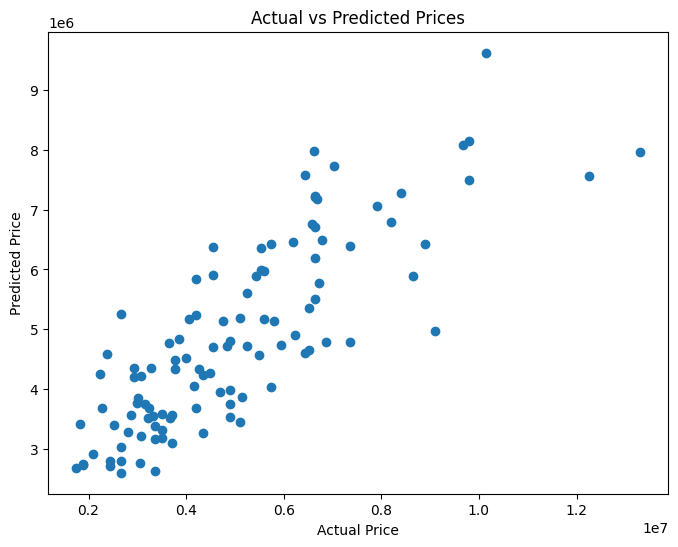

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

**Expected Interpretation**

Simple Linear Regression


*   Area is used as the only predictor.
*   As area increases, house price generally
*  Regression line shows the relationship between area and price.
*  R² score indicates how much variation in price is explained by area alone.

Multiple Linear Regression

*   Uses all available features.
*   Usually achieves a higher R² score than simple regression.
*  Features such as bathrooms, air conditioning, parking, and preferred area positively influence house prices.
* Coefficients indicate how strongly each feature affects price.




